# Import packages and Observe dataset

In [1]:
# Import numerical libraries
import seaborn as sns
import numpy as np

# Import graphical plotting libraries
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Import Linear Regression Machine Learning Libraries
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score

In [3]:
data=pd.read_csv(r"C:\Users\suraj\Downloads\car-mpg.csv")

In [5]:
data

,mpg,cyl,disp,hp,wt,acc,yr,origin,car_type,car_name
0,18.0,8,307.0,130,3504,12.0,70,1,0,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,0,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,0,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,0,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,0,ford torino
...,...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,1,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,1,ford ranger


In [7]:
# Drop car name
# Replace origin into 1,2,3.. dont forget get_dummies
# Replace ? with nan
# Replace all nan with median

data=data.drop(['car_name'],axis=1)
data['origin']=data['origin'].replace({1:'america',2:'europe',3:'asia'})
data=pd.get_dummies(data,columns=['origin'],dtype=int)

import numpy as np
data=data.replace('?',np.nan)
data=data.apply(pd.to_numeric,errors='ignore')

#fill median only for numeric columns
data=data.apply(lambda x:x.fillna(x.median())if x.dtype !='object' else x,axis=0)

C:\Users\suraj\AppData\Local\Temp\ipykernel_31036\604610712.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data=data.apply(pd.to_numeric,errors='ignore')


In [9]:
data.head()

,mpg,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,18.0,8,307.0,130.0,3504,12.0,70,0,1,0,0
1,15.0,8,350.0,165.0,3693,11.5,70,0,1,0,0
2,18.0,8,318.0,150.0,3436,11.0,70,0,1,0,0
3,16.0,8,304.0,150.0,3433,12.0,70,0,1,0,0
4,17.0,8,302.0,140.0,3449,10.5,70,0,1,0,0


# Model Building

In [12]:
# We have to predict the mpg column given the feature
x=data.drop(['mpg'],axis=1) # independent variable
y=data[['mpg']] # dependent variable


In [14]:
x.head(3)

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,8,307.0,130.0,3504,12.0,70,0,1,0,0
1,8,350.0,165.0,3693,11.5,70,0,1,0,0
2,8,318.0,150.0,3436,11.0,70,0,1,0,0


In [16]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


In [18]:
x_s=preprocessing.scale(x)

In [20]:
x_s

array([[ 1.49819126,  1.0906037 ,  0.67311762, ...,  0.77355903,
        -0.49764335, -0.46196822],
       [ 1.49819126,  1.5035143 ,  1.58995818, ...,  0.77355903,
        -0.49764335, -0.46196822],
       [ 1.49819126,  1.19623199,  1.19702651, ...,  0.77355903,
        -0.49764335, -0.46196822],
       ...,
       [-0.85632057, -0.56103873, -0.53187283, ...,  0.77355903,
        -0.49764335, -0.46196822],
       [-0.85632057, -0.70507731, -0.66285006, ...,  0.77355903,
        -0.49764335, -0.46196822],
       [-0.85632057, -0.71467988, -0.58426372, ...,  0.77355903,
        -0.49764335, -0.46196822]])

In [22]:
y_s=preprocessing.scale(y)
y_s

array([[-7.06438701e-01],
       [-1.09075062e+00],
       [-7.06438701e-01],
       [-9.62646649e-01],
       [-8.34542675e-01],
       [-1.09075062e+00],
       [-1.21885460e+00],
       [-1.21885460e+00],
       [-1.21885460e+00],
       [-1.09075062e+00],
       [-1.09075062e+00],
       [-1.21885460e+00],
       [-1.09075062e+00],
       [-1.21885460e+00],
       [ 6.21851453e-02],
       [-1.94022803e-01],
       [-7.06438701e-01],
       [-3.22126778e-01],
       [ 4.46497068e-01],
       [ 3.18393094e-01],
       [ 1.90289120e-01],
       [ 6.21851453e-02],
       [ 1.90289120e-01],
       [ 3.18393094e-01],
       [-3.22126778e-01],
       [-1.73127050e+00],
       [-1.73127050e+00],
       [-1.60316652e+00],
       [-1.85937447e+00],
       [ 4.46497068e-01],
       [ 5.74601043e-01],
       [ 1.90289120e-01],
       [ 1.90289120e-01],
       [-5.78334726e-01],
       [-9.62646649e-01],
       [-8.34542675e-01],
       [-5.78334726e-01],
       [-7.06438701e-01],
       [-1.2

In [24]:
x_s = pd.DataFrame(x_s, columns=x.columns)
y_s = pd.DataFrame(y_s, columns=y.columns)

In [26]:
x_s

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe
0,1.498191,1.090604,0.673118,0.630870,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
1,1.498191,1.503514,1.589958,0.854333,-1.477038,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
2,1.498191,1.196232,1.197027,0.550470,-1.658577,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
3,1.498191,1.061796,1.197027,0.546923,-1.295498,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
4,1.498191,1.042591,0.935072,0.565841,-1.840117,-1.627426,-1.062235,0.773559,-0.497643,-0.461968
...,...,...,...,...,...,...,...,...,...,...
393,-0.856321,-0.513026,-0.479482,-0.213324,0.011586,1.621983,0.941412,0.773559,-0.497643,-0.461968
394,-0.856321,-0.925936,-1.370127,-0.993671,3.279296,1.621983,0.941412,-1.292726,-0.497643,2.164651
395,-0.856321,-0.561039,-0.531873,-0.798585,-1.440730,1.621983,0.941412,0.773559,-0.497643,-0.461968
396,-0.856321,-0.705077,-0.662850,-0.408411,1.100822,1.621983,0.941412,0.773559,-0.497643,-0.461968


In [28]:
x_train,x_test,y_train,y_test=train_test_split(x_s,y_s,test_size=0.3,random_state=0)

In [30]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(278, 10)
(120, 10)
(278, 1)
(120, 1)


In [32]:
len(data)

398

# Simple Linear Model

In [35]:
regression_model=LinearRegression()
regression_model.fit(x_train,y_train)

for idx,col_name in enumerate(x_train.columns):
    print('The coef for{}is{}'.format(col_name,regression_model.coef_[0][idx]))

print('======')

intercept=regression_model.intercept_[0]
print('The intercept is{}'.format(intercept))

print('======')

The coef forcylis0.24744479758946641
The coef fordispis0.28838215446098786
The coef forhpis-0.1899034268715291
The coef forwtis-0.6732229065111776
The coef foraccis0.06754501540688125
The coef foryris0.3446364072117279
The coef forcar_typeis0.3149149154003764
The coef fororigin_americais-0.07682943694882848
The coef fororigin_asiais0.06336048896619992
The coef fororigin_europeis0.03128335735147545
The intercept is-0.019500467624017432


#  Regularized Ridge Regression model

In [40]:
#alpha factor here is lambda (penalty term) which helps to reduce the magnitude of coeff

ridge_model = Ridge(alpha = 0.3)
ridge_model.fit(x_train, y_train)

print('Ridge model coef: {}'.format(ridge_model.coef_))
#As the data has 10 columns hence 10 coefficients appear here    

Ridge model coef: [[ 0.24424435  0.27853222 -0.18980689 -0.66458446  0.06588077  0.34396213
   0.31169746 -0.07642734  0.06333336  0.03080065]]


# Regularized Lasso Regression model

In [45]:
#alpha factor here is lambda (penalty term) which helps to reduce the magnitude of coeff

lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(x_train, y_train)

print('Lasso model coef: {}'.format(lasso_model.coef_))
#As the data has 10 columns hence 10 coefficients appear here   

Lasso model coef: [-0.         -0.         -0.06203044 -0.48363379  0.          0.27163751
  0.09620861 -0.03490256  0.          0.        ]


# Score Comparison

In [50]:
#Model score - r^2 or coeff of determinant
#r^2 = 1-(RSS/TSS) = Regression error/TSS 


#Simple Linear Model
print(regression_model.score(x_train, y_train))
print(regression_model.score(x_test, y_test))

print('*************************')
#Ridge
print(ridge_model.score(x_train, y_train))
print(ridge_model.score(x_test, y_test))

print('*************************')
#Lasso
print(lasso_model.score(x_train, y_train))
print(lasso_model.score(x_test, y_test))

0.8361638001149431
0.8439452810748138
*************************
0.8361520170844985
0.8437853815947183
*************************
0.7994535676270828
0.81026554865651


# Model Parameter Tuning

In [58]:
data_train_test = pd.concat([x_train, y_train], axis =1)
data_train_test.head()

,cyl,disp,hp,wt,acc,yr,car_type,origin_america,origin_asia,origin_europe,mpg
230,1.498191,1.503514,1.720935,1.412400,-1.513346,0.268063,-1.062235,0.773559,-0.497643,-0.461968,-1.026699
357,-0.856321,-0.714680,-0.112746,-0.420234,-0.278877,1.351199,0.941412,-1.292726,2.009471,-0.461968,1.202311
140,1.498191,1.061796,1.197027,1.521175,-0.024722,-0.544290,-1.062235,0.773559,-0.497643,-0.461968,-1.218855
22,-0.856321,-0.858718,-0.243723,-0.703997,0.701436,-1.627426,0.941412,-1.292726,-0.497643,2.164651,0.190289
250,1.498191,1.196232,0.935072,0.903991,-0.859804,0.538847,-1.062235,0.773559,-0.497643,-0.461968,-0.527093


In [60]:
import statsmodels.formula.api as smf
ols1 = smf.ols(formula = 'mpg ~ cyl+disp+hp+wt+acc+yr+car_type+origin_america+origin_europe+origin_asia', data = data_train_test).fit()
ols1.params

Intercept        -0.019500
cyl               0.247445
disp              0.288382
hp               -0.189903
wt               -0.673223
acc               0.067545
yr                0.344636
car_type          0.314915
origin_america   -0.076829
origin_europe     0.031283
origin_asia       0.063360
dtype: float64

In [62]:
print(ols1.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     152.0
Date:                Thu, 11 Jun 2026   Prob (F-statistic):          7.34e-100
Time:                        15:16:39   Log-Likelihood:                -139.91
No. Observations:                 278   AIC:                             299.8
Df Residuals:                     268   BIC:                             336.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.0195      0.025     -0.

In [64]:
#Lets check Sum of Squared Errors (SSE) by predicting value of y for test cases and subtracting from the actual y for the test cases
mse  = np.mean((regression_model.predict(x_test)-y_test)**2)

# root of mean_sq_error is standard deviation i.e. avg variance between predicted and actual
import math
rmse = math.sqrt(mse)
print('Root Mean Squared Error: {}'.format(rmse))

Root Mean Squared Error: 0.4045366587848481


In [68]:
# Is OLS a good model ? Lets check the residuals for some of these predictor.

fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['hp'], y= y_test['mpg'], color='green', lowess=True )


fig = plt.figure(figsize=(10,8))
sns.residplot(x= x_test['acc'], y= y_test['mpg'], color='green', lowess=True )

<Axes: xlabel='acc', ylabel='mpg'>

<Figure size 1000x800 with 0 Axes>

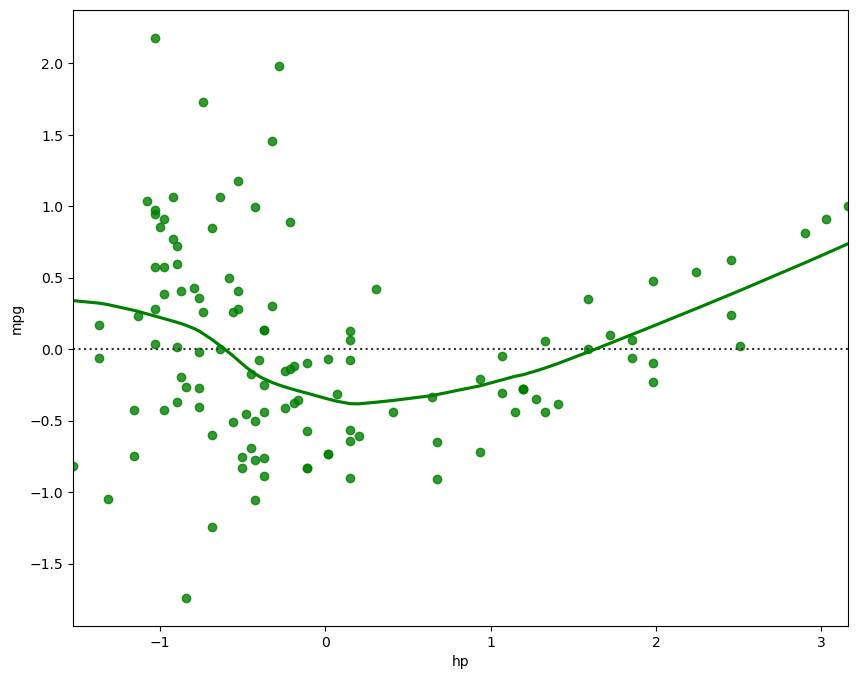

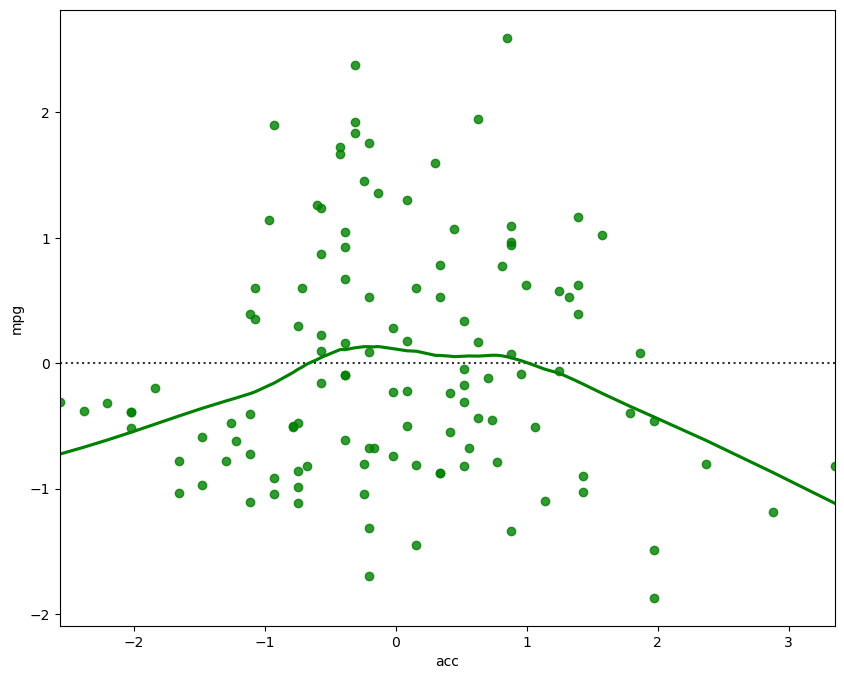

In [70]:
plt.show()